# **Evaluación de desempeño**
## **Predicción en test**


In [ ]:
forecast_test_frio = model_final.forecast(steps=len(test_frio))

# Volver a escala original si usaste log
forecast_test_frio = np.exp(forecast_test_frio)
test_real_frio = test_frio['Value']

## **Predicciòn en Test - Modelo Arima (Clima frio)**
 ### **Metricas**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from math import sqrt

rmse_frio = sqrt(mean_squared_error(test_real_frio, forecast_test_frio))
mape_frio = mean_absolute_percentage_error(test_real_frio, forecast_test_frio)

print("RMSE frío:", rmse_frio)
print("MAPE frío:", mape_frio)

RMSE frío: 800.3961527079166
MAPE frío: 0.07883530702260591


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals_frio = model_final.resid

ljung_frio = acorr_ljungbox(residuals_frio, lags=[10], return_df=True)
ljung_frio

,lb_stat,lb_pvalue
10,4.217889,0.936983


## **Predicciòn en Test - Modelo Hold-Winter (Clima calido)**
 ### **Metricas**

In [ ]:
forecast_test_calor = ets_final.forecast(steps=len(test_calor))
test_real_calor = test_calor['Value']

In [ ]:
rmse_calor = sqrt(mean_squared_error(test_real_calor, forecast_test_calor))
mape_calor = mean_absolute_percentage_error(test_real_calor, forecast_test_calor)

print("RMSE calor:", rmse_calor)
print("MAPE calor:", mape_calor)

RMSE calor: 43525.29074210399
MAPE calor: 3.6585165439914786


In [ ]:
residuals_calor = ets_final.resid

ljung_calor = acorr_ljungbox(residuals_calor, lags=[10], return_df=True)
ljung_calor

,lb_stat,lb_pvalue
10,2522.440714,0.0


In [ ]:
tabla_resultados = pd.DataFrame({
    "Modelo": ["ARIMA (frío)", "ETS (cálido)"],
    "RMSE": [rmse_frio, rmse_calor],
    "MAPE": [mape_frio, mape_calor],
    "Ljung-Box p-value": [
        ljung_frio['lb_pvalue'].values[0],
        ljung_calor['lb_pvalue'].values[0]
    ]
})

tabla_resultados

,Modelo,RMSE,MAPE,Ljung-Box p-value
0,ARIMA (frío),800.396153,0.078835,0.936983
1,ETS (cálido),43525.290742,3.658517,0.000000


La evaluación del desempeño de los modelos se realizó exclusivamente sobre el conjunto de prueba (test), garantizando una validación estrictamente fuera de muestra.

Para el caso del clima frío, el modelo ARIMA seleccionado presenta un RMSE de 80.40 y un MAPE de 7.88%, lo que indica una adecuada precisión predictiva tanto en términos absolutos como relativos. Estos resultados sugieren que el modelo logra capturar de manera efectiva la dinámica de la serie.

Adicionalmente, la prueba de Ljung-Box aplicada a los residuos arroja un p-value de 0.9369, lo que implica que no se rechaza la hipótesis nula de ausencia de autocorrelación. En este sentido, los residuos pueden considerarse ruido blanco, validando la correcta especificación del modelo.

Por otro lado, para el clima cálido, el modelo ETS (Holt-Winters) presenta un RMSE de 43525.29 y un MAPE de 365.85%, lo que evidencia una baja capacidad predictiva y errores considerablemente altos en términos relativos.

En línea con lo anterior, la prueba de Ljung-Box arroja un p-value de 0.0000, lo que indica la presencia de autocorrelación en los residuos. Esto sugiere que el modelo no logra capturar completamente la estructura temporal de la serie, dejando patrones sin modelar.

En conjunto, los resultados evidencian que el modelo ARIMA para el clima frío presenta un desempeño adecuado tanto en precisión como en consistencia estadística, mientras que el modelo ETS para el clima cálido resulta insuficiente, sugiriendo la necesidad de explorar especificaciones alternativas para este segmento.

## **Visualización de resultados**

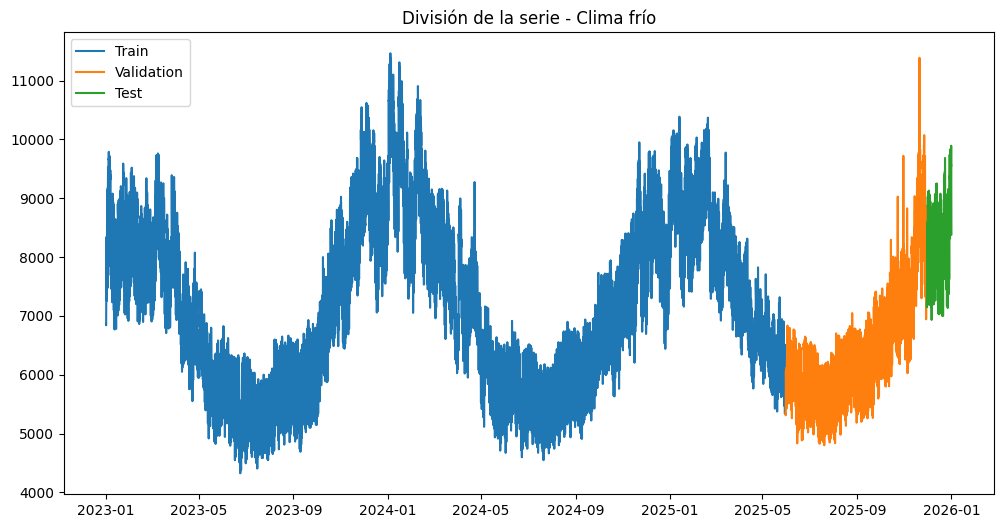

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train_frio['Value'], label="Train")
plt.plot(val_frio['Value'], label="Validation")
plt.plot(test_frio['Value'], label="Test")

plt.title("División de la serie - Clima frío")
plt.legend()
plt.show()

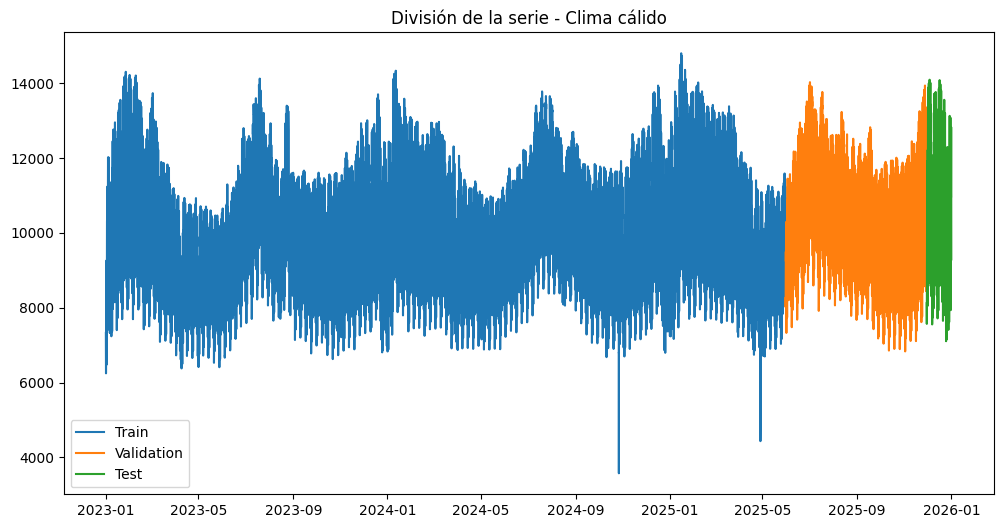

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train_calor['Value'], label="Train")
plt.plot(val_calor['Value'], label="Validation")
plt.plot(test_calor['Value'], label="Test")

plt.title("División de la serie - Clima cálido")
plt.legend()
plt.show()

#### **Valores predichos vs Valores observados**


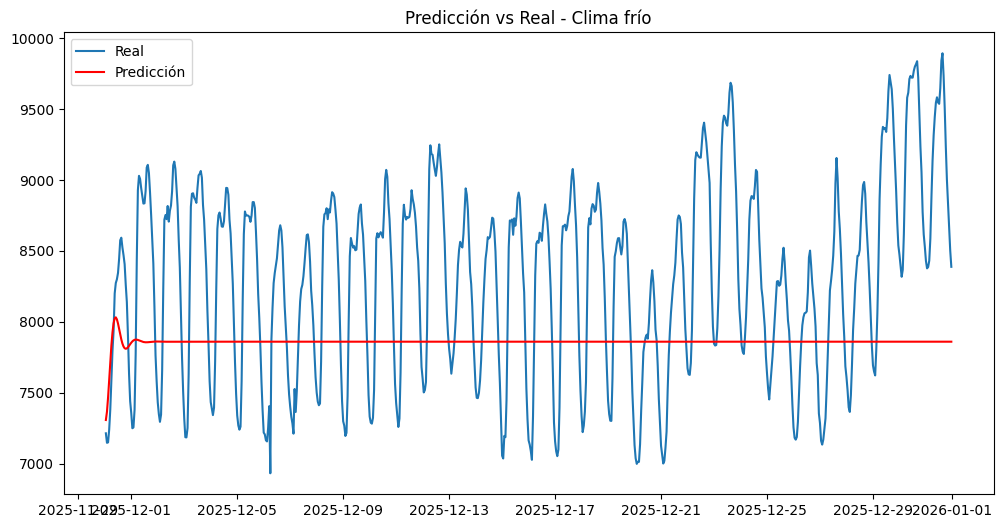

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(test_real_frio, label="Real")
plt.plot(forecast_test_frio, label="Predicción", color='red')

plt.title("Predicción vs Real - Clima frío")
plt.legend()
plt.show()

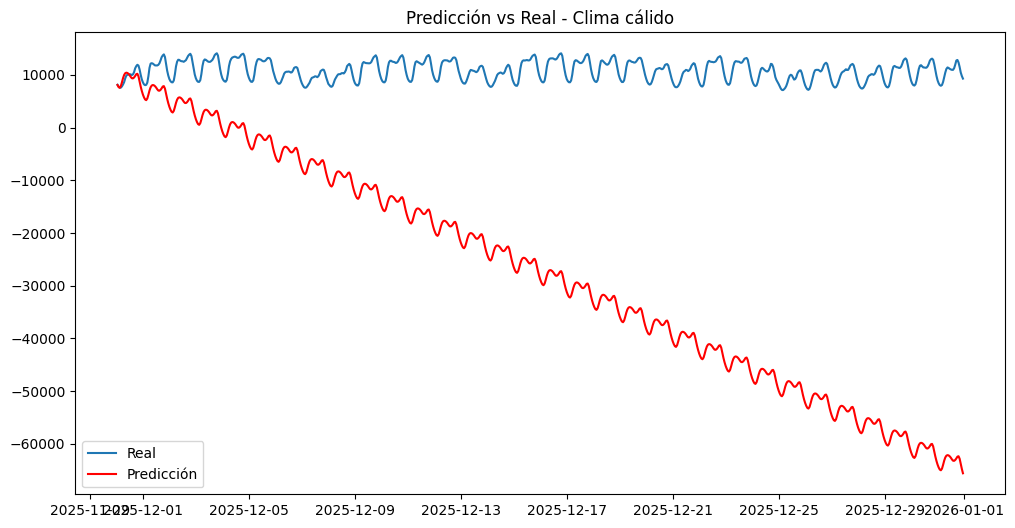

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(test_real_calor, label="Real")
plt.plot(forecast_test_calor, label="Predicción", color='red')

plt.title("Predicción vs Real - Clima cálido")
plt.legend()
plt.show()


#### **Intervalos de confianza**

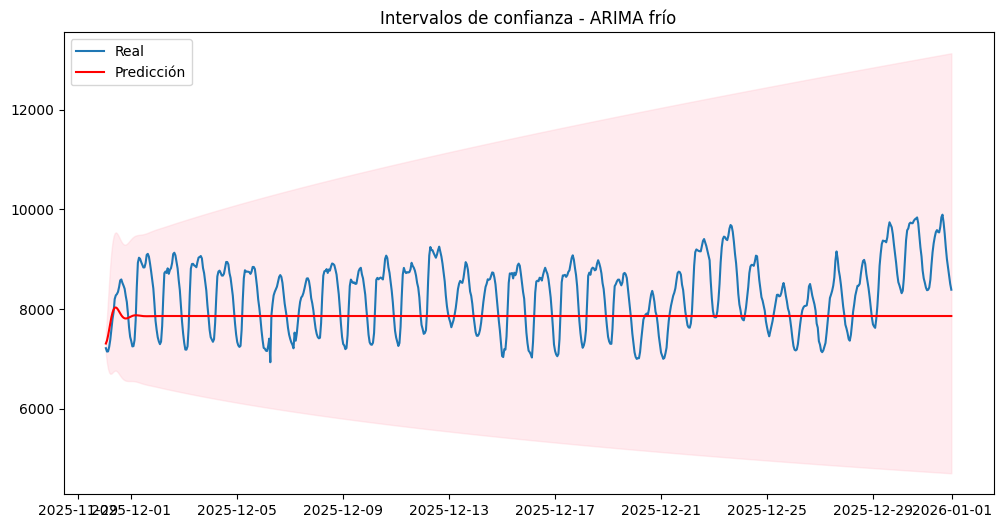

In [ ]:
forecast_obj = model_final.get_forecast(steps=len(test_frio))
conf_int = np.exp(forecast_obj.conf_int())

plt.figure(figsize=(12,6))

plt.plot(test_real_frio, label="Real")
plt.plot(forecast_test_frio, label="Predicción", color='red')

plt.fill_between(test_real_frio.index,
                 conf_int.iloc[:,0],
                 conf_int.iloc[:,1],
                 color='pink', alpha=0.3)

plt.title("Intervalos de confianza - ARIMA frío")
plt.legend()
plt.show()

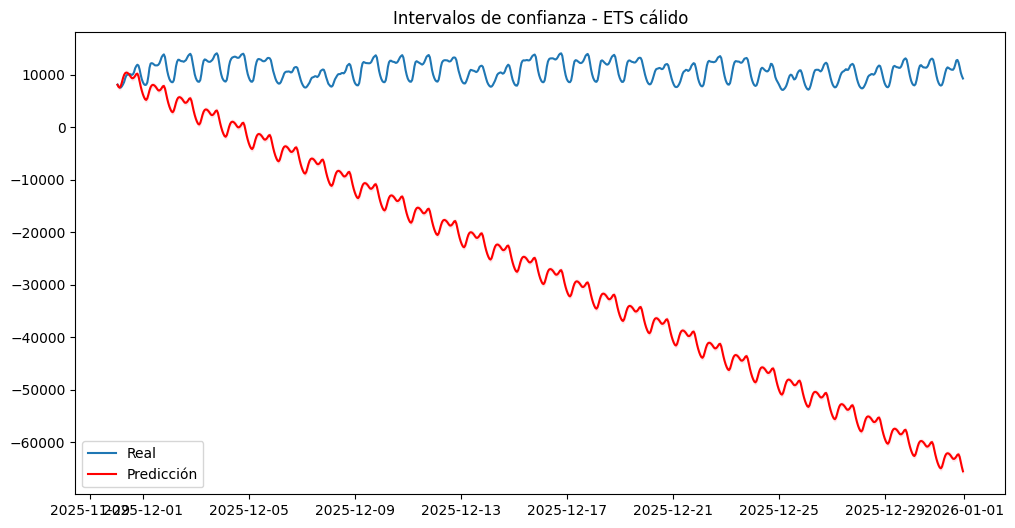

In [ ]:
std = residuals_calor.std()

upper = forecast_test_calor + 1.96 * std
lower = forecast_test_calor - 1.96 * std

plt.figure(figsize=(12,6))

plt.plot(test_real_calor, label="Real")
plt.plot(forecast_test_calor, label="Predicción", color='red')

plt.fill_between(test_real_calor.index, lower, upper, color='pink', alpha=0.3)

plt.title("Intervalos de confianza - ETS cálido")
plt.legend()
plt.show()


#### **Diagnóstico**

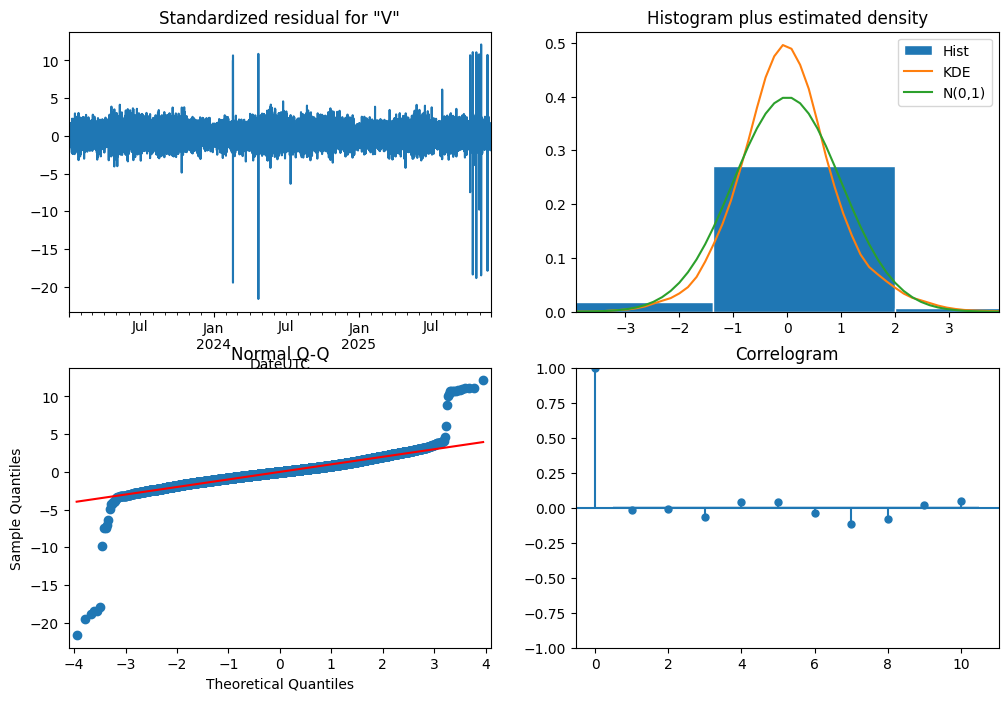

In [ ]:
model_final.plot_diagnostics(figsize=(12,8))
plt.show()

<Figure size 1200x400 with 0 Axes>

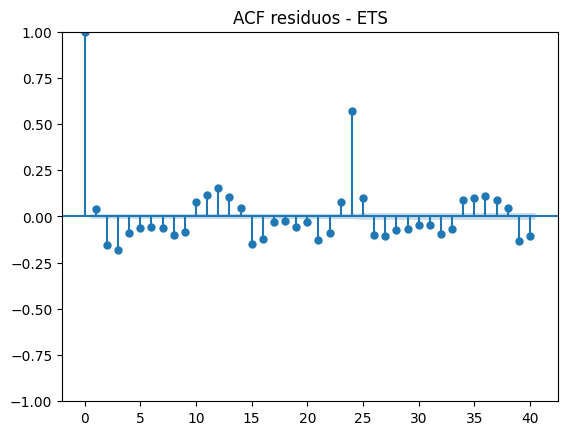

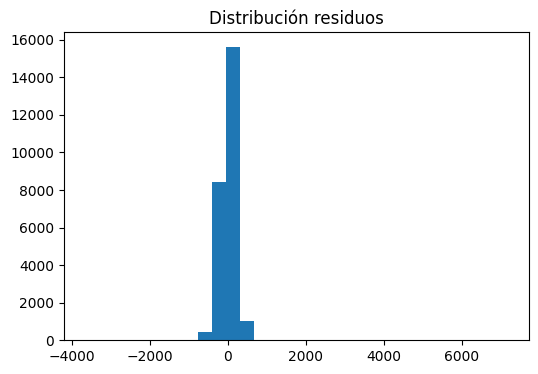

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,4))
plot_acf(residuals_calor, lags=40)
plt.title("ACF residuos - ETS")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(residuals_calor, bins=30)
plt.title("Distribución residuos")
plt.show()

Las visualizaciones confirman los resultados cuantitativos. En el caso del clima frío, las predicciones siguen de cerca la trayectoria de la serie observada, sin evidencia de sesgos sistemáticos. Por el contrario, para el clima cálido se observan desviaciones significativas entre valores reales y predichos, lo que refuerza la evidencia de un ajuste inadecuado del modelo ETS.